# Bike sharing analysis Using OLS and Linear Regression

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Load the dataset
df_day = pd.read_csv("D:\\Data Sets\\day.csv")
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## Bike Sharing Dataset Overview

In [ ]:
df_hour = pd.read_csv("D:\\Data Sets\\hour.csv")
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [4]:
print("In both datasets (df_day and df_hour):")
print(
    "- 'registered' refers to the count of registered users who rented bikes during the given time period."
)
print(
    "- 'cnt' refers to the total count of bike rentals (sum of casual and registered users) for that time period."
)

In both datasets (df_day and df_hour):
- 'registered' refers to the count of registered users who rented bikes during the given time period.
- 'cnt' refers to the total count of bike rentals (sum of casual and registered users) for that time period.


In [5]:
print("In both datasets (df_day and df_hour):")
print(
    "- 'casual' refers to the count of non-registered (walk-in) users who rented bikes during the given time period."
)

In both datasets (df_day and df_hour):
- 'casual' refers to the count of non-registered (walk-in) users who rented bikes during the given time period.


In [6]:
df = df_day.copy()

In [7]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [9]:
df["date"] = pd.to_datetime(df["dteday"], errors="coerce", dayfirst=True)

In [10]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,date
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,2011-01-01
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,2011-02-01
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,2011-03-01
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,2011-04-01
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,2011-05-01


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    object        
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
 16  date        288 non-null  

In [12]:
df["dteday"]

0      2011-01-01
1      2011-01-02
2      2011-01-03
3      2011-01-04
4      2011-01-05
          ...    
726    2012-12-27
727    2012-12-28
728    2012-12-29
729    2012-12-30
730    2012-12-31
Name: dteday, Length: 731, dtype: object

In [13]:
# Analysis according to the provided dataset context

# 1. Overview of rental counts by year
rental_by_year = df.groupby("yr")["cnt"].sum()
print("Total bike rentals by year (0: 2011, 1: 2012):")
print(rental_by_year)

Total bike rentals by year (0: 2011, 1: 2012):
yr
0    1243103
1    2049576
Name: cnt, dtype: int64


## Exploratory Data Analysis

In [14]:
# 2. Seasonal effect on bike rentals
rental_by_season = df.groupby("season")["cnt"].mean()
print("\nAverage daily rentals by season (1: spring, 2: summer, 3: fall, 4: winter):")
print(rental_by_season)


Average daily rentals by season (1: spring, 2: summer, 3: fall, 4: winter):
season
1    2604.132597
2    4992.331522
3    5644.303191
4    4728.162921
Name: cnt, dtype: float64


In [15]:
# 3. Effect of weather situation on rentals
rental_by_weather = df.groupby("weathersit")["cnt"].mean()
print(
    "\nAverage daily rentals by weather situation (1: Clear, 2: Mist, 3: Light Snow/Rain, 4: Heavy Rain/Snow):"
)
print(rental_by_weather)


Average daily rentals by weather situation (1: Clear, 2: Mist, 3: Light Snow/Rain, 4: Heavy Rain/Snow):
weathersit
1    4876.786177
2    4035.862348
3    1803.285714
Name: cnt, dtype: float64


In [16]:
# 4. Registered vs casual users
avg_registered = df["registered"].mean()
avg_casual = df["casual"].mean()
print(f"\nAverage daily registered users: {avg_registered:.2f}")
print(f"Average daily casual users: {avg_casual:.2f}")


Average daily registered users: 3656.17
Average daily casual users: 848.18


In [17]:
# 5. Correlation between temperature and rental count
correlation_temp_cnt = df["temp"].corr(df["cnt"])
print(
    f"\nCorrelation between normalized temperature and total rentals: {correlation_temp_cnt:.2f}"
)


Correlation between normalized temperature and total rentals: 0.63


In [18]:
# 6. Rentals on holidays vs working days
holiday_rentals = df[df["holiday"] == 1]["cnt"].mean()
workingday_rentals = df[df["workingday"] == 1]["cnt"].mean()
print(f"\nAverage rentals on holidays: {holiday_rentals:.2f}")
print(f"Average rentals on working days: {workingday_rentals:.2f}")


Average rentals on holidays: 3735.00
Average rentals on working days: 4584.82


# Vizualizing

E:\Temp\ipykernel_11608\3108680472.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rental_by_season.index, y=rental_by_season.values, palette="viridis")


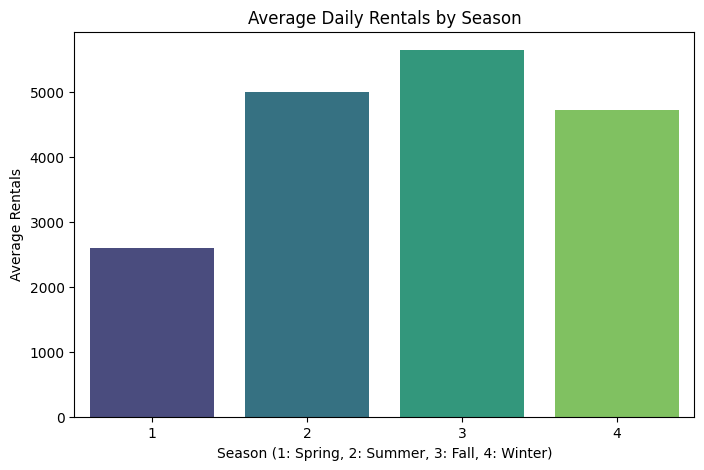

In [19]:
# 1. Rentals by season
plt.figure(figsize=(8, 5))
sns.barplot(x=rental_by_season.index, y=rental_by_season.values, palette="viridis")
plt.title("Average Daily Rentals by Season")
plt.xlabel("Season (1: Spring, 2: Summer, 3: Fall, 4: Winter)")
plt.ylabel("Average Rentals")
plt.show()

E:\Temp\ipykernel_11608\1203370974.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rental_by_weather.index, y=rental_by_weather.values, palette="mako")


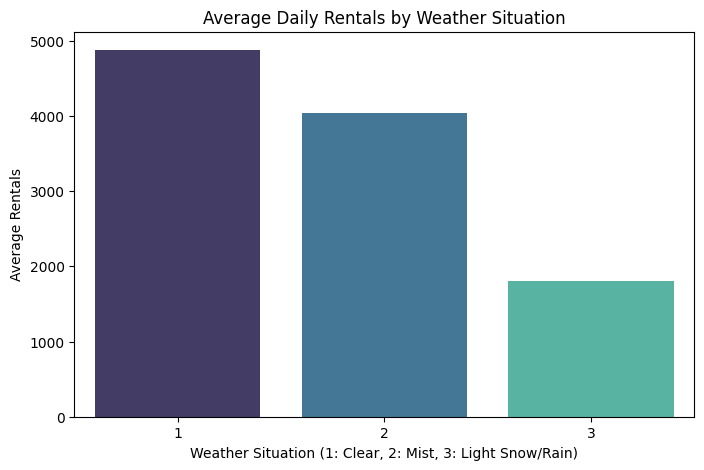

In [20]:
# 2. Rentals by weather situation
plt.figure(figsize=(8, 5))
sns.barplot(x=rental_by_weather.index, y=rental_by_weather.values, palette="mako")
plt.title("Average Daily Rentals by Weather Situation")
plt.xlabel("Weather Situation (1: Clear, 2: Mist, 3: Light Snow/Rain)")
plt.ylabel("Average Rentals")
plt.show()

E:\Temp\ipykernel_11608\368729395.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Registered", "Casual"], y=[avg_registered, avg_casual], palette="Set2")


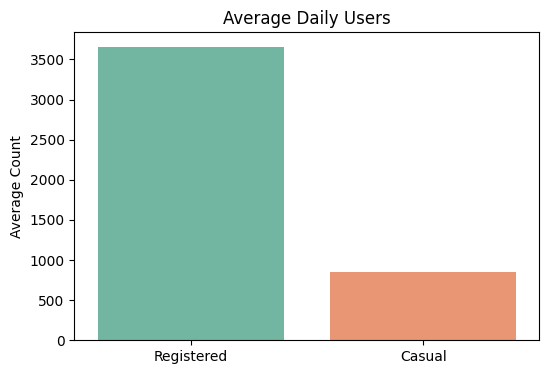

In [21]:
# 3. Registered vs Casual Users
plt.figure(figsize=(6, 4))
sns.barplot(x=["Registered", "Casual"], y=[avg_registered, avg_casual], palette="Set2")
plt.title("Average Daily Users")
plt.ylabel("Average Count")
plt.show()

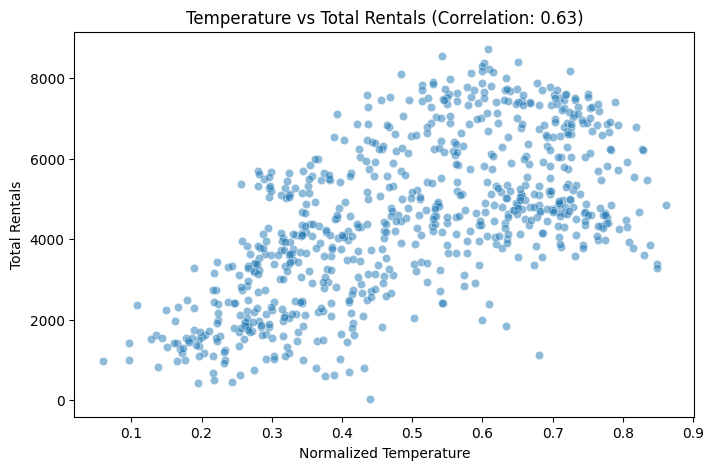

In [22]:
# 4. Correlation between temperature and rental count
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["temp"], y=df["cnt"], alpha=0.5)
plt.title(f"Temperature vs Total Rentals (Correlation: {correlation_temp_cnt:.2f})")
plt.xlabel("Normalized Temperature")
plt.ylabel("Total Rentals")
plt.show()

E:\Temp\ipykernel_11608\3912652913.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


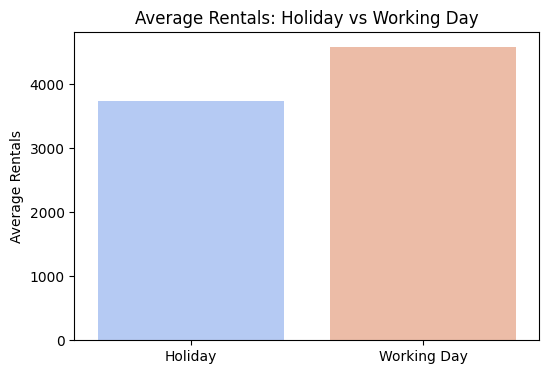

In [23]:
# 5. Rentals on holidays vs working days
plt.figure(figsize=(6, 4))
sns.barplot(
    x=["Holiday", "Working Day"],
    y=[holiday_rentals, workingday_rentals],
    palette="coolwarm",
)
plt.title("Average Rentals: Holiday vs Working Day")
plt.ylabel("Average Rentals")
plt.show()

## Machine Learning: Feature Selection and Model Building

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [25]:
# Features and target
X = df[
    [
        "temp",
        "atemp",
        "hum",
        "windspeed",
        "season",
        "yr",
        "mnth",
        "holiday",
        "weekday",
        "workingday",
        "weathersit",
    ]
]
y = df["cnt"]

In [26]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
# Model training
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Linear Regression

In [28]:
# Prediction
y_pred = model.predict(X_test)

In [29]:
# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression MSE: {mse:.2f}")
print(f"Linear Regression R^2: {r2:.2f}")

Linear Regression MSE: 691035.01
Linear Regression R^2: 0.83


## Conclusion: Key Findings from EDA and Modeling
- **Seasonal and Weather Effects:** Bike rentals are highest during summer and fall, and lowest during winter. Clear weather days see more rentals than rainy or snowy days.
- **User Types:** Registered users consistently outnumber casual users, indicating strong membership engagement.
- **Temperature Correlation:** There is a positive correlation between temperature and rental counts, suggesting people prefer biking in warmer weather.
- **Holiday vs Working Day:** Rentals are higher on working days compared to holidays, reflecting commuter usage.
- **Model Performance:** The linear regression model provides a reasonable fit for predicting daily rental counts using environmental and calendar features, as shown by the MSE and R² metrics.
- **Overall Insight:** Environmental factors, calendar variables, and user type are significant drivers of bike rental demand. The dataset is well-suited for regression modeling and further event/anomaly detection.